In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

In [7]:

dataset_dir = r"C:\Users\Promi\Downloads\archive\train" 


IMG_SIZE = (32, 32)
BATCH_SIZE = 64

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes found:", class_names)

Found 100000 files belonging to 2 classes.
Using 80000 files for training.
Found 100000 files belonging to 2 classes.
Using 20000 files for validation.
Classes found: ['FAKE', 'REAL']


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [10]:
model = models.Sequential([
    # পিক্সেলে মান ০-২৫৫ থেকে ০-১ এর মধ্যে আনা
    layers.Rescaling(1./255, input_shape=(32, 32, 3)),
    
    # ১ম কনভোলিউশনাল লেয়ার
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # ২য় কনভোলিউশনাল লেয়ার
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # ৩য় কনভোলিউশনাল লেয়ার
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # ডেন্স লেয়ার (Classification)
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # ওভারফিটিং রোধ করতে
    layers.Dense(1, activation='sigmoid') # 0 = FAKE, 1 = REAL (অথবা আলফাবেটিক্যাল ক্রমানুসারে)
])

# মডেল কম্পাইল করা
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 159,041 (621.25 KB)

 Trainable params: 159,041 (621.25 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.9610 - loss: 0.1001 - val_accuracy: 0.9244 - val_loss: 0.2395
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.9632 - loss: 0.0952 - val_accuracy: 0.9297 - val_loss: 0.1940
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.9671 - loss: 0.0842 - val_accuracy: 0.9137 - val_loss: 0.2889
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.9700 - loss: 0.0774 - val_accuracy: 0.9331 - val_loss: 0.2300
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.9735 - loss: 0.0687 - val_accuracy: 0.9286 - val_loss: 0.2514
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.9729 - loss: 0.0702 - val_accuracy: 0.9238 - val_loss: 0.2621
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - accuracy: 0.9775 - loss: 0.0604 - val_accuracy: 0.9290 - val_loss: 0.2630
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.9775 -

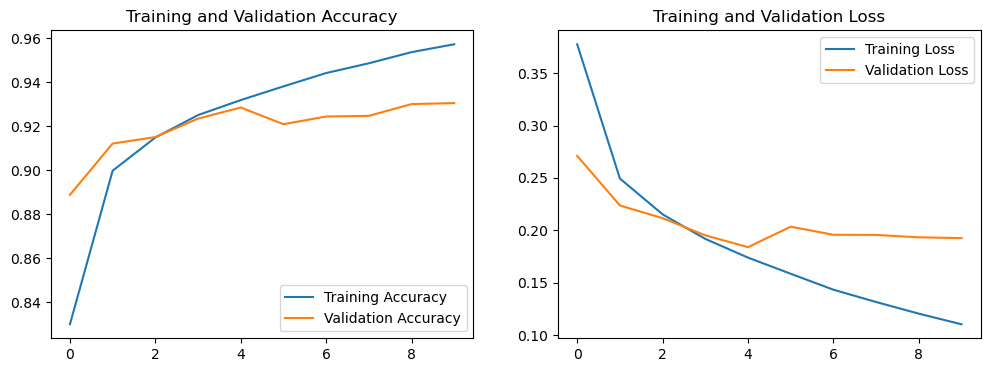

In [12]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

In [14]:
# .keras extraction save.

model.save('../models/ai_real_detector.keras')

print("Model successfully saved in native Keras format!")

Model successfully saved in native Keras format!


In [24]:
import numpy as np
from tensorflow.keras.preprocessing import image

# ১. প্রেডিকশন করার ফাংশন
def predict_image(img_path):
    test_img = image.load_img(img_path, target_size=(32, 32))
    img_array = image.img_to_array(test_img)
    img_array = np.expand_dims(img_array, axis=0) # Batch Dimension

    result = model.predict(img_array)
    confidence = result[0][0]

    # আপনার ক্লাসের আলফাবেটিক্যাল অর্ডার অনুযায়ী (FAKE = 0, REAL = 1)
    if confidence > 0.5:
        print(f"Prediction: REAL Image (Confidence: {confidence*100:.2f}%)")
    else:
        print(f"Prediction: AI / FAKE Image (Confidence: {(1-confidence)*100:.2f}%)")

# ২. টেস্ট ছবির পাথ
test_image_path = r"C:\Users\Promi\Downloads\WhatsApp Image 2026-05-02 at 11.47.03 AM-32x32.jpeg" 



# ৩. কল করা
predict_image(test_image_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Prediction: REAL Image (Confidence: 97.66%)
